In [ ]:
# Full PS7 pipeline 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint as sp_randint
import joblib
import warnings
warnings.filterwarnings("ignore")

# ---------- User-tunable settings ----------
DATA_PATH = "biden.csv"          # path to your dataset
RANDOM_STATE = 25
TEST_SIZE = 0.30

# Tuning complexity (match assignment)
N_ITER_DT = 100   # iterations for DecisionTree RandomizedSearchCV (assignment requires 100)
N_ITER_RF = 100   # iterations for RandomForest RandomizedSearchCV
CV = 5            # number of CV folds

# ---------- Load data ----------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find '{DATA_PATH}'. Download biden.csv and place in working directory.")

df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values and dtypes
print("\nMissing values per column:")
print(df.isna().sum())

print("\nColumn dtypes:")
print(df.dtypes)


Data shape: (1807, 6)
Columns: ['biden', 'female', 'age', 'educ', 'dem', 'rep']

First 5 rows:
   biden  female  age  educ  dem  rep
0     90       0   19    12    1    0
1     70       1   51    14    1    0
2     60       0   27    14    0    0
3     50       1   43    14    1    0
4     60       1   38    14    0    1

Missing values per column:
biden     0
female    0
age       0
educ      0
dem       0
rep       0
dtype: int64

Column dtypes:
biden     int64
female    int64
age       int64
educ      int64
dem       int64
rep       int64
dtype: object


In [3]:
# ---------- Prepare X, y (safe numeric-only + simple imputation) ----------
if 'biden' not in df.columns:
    raise KeyError("Expected target column named 'biden' in the CSV.")
y = df['biden']

# Keep only numeric predictors (safe for sklearn regressors)
X_all = df.drop(columns=['biden'])
numeric_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in X_all.columns if c not in numeric_cols]
if non_numeric_cols:
    print(f"Warning: dropping non-numeric columns: {non_numeric_cols}")
X = X_all[numeric_cols].copy()

# Impute numeric NaNs with median (tree models handle this well)
if X.isna().any().any():
    print("Imputing numeric NaNs with column medians.")
    X = X.fillna(X.median())

# Drop any rows with NaN target
mask_target = y.notna()
if not mask_target.all():
    print(f"Dropping {(~mask_target).sum()} rows with NaN target.")
    X = X.loc[mask_target].reset_index(drop=True)
    y = y.loc[mask_target].reset_index(drop=True)
else:
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

print(f"\nTarget variable (biden) stats:")
print(f"Mean: {y.mean():.2f}, Std: {y.std():.2f}, Min: {y.min()}, Max: {y.max()}")




Target variable (biden) stats:
Mean: 62.16, Std: 23.46, Min: 0, Max: 100


In [4]:

# ---------- Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"\nTrain shape: {X_train.shape}; Test shape: {X_test.shape}")




Train shape: (1264, 5); Test shape: (543, 5)



PART 1: Basic Decision Tree
Decision Tree (depth=3, min_samples_leaf=5) Test MSE: 396.1937


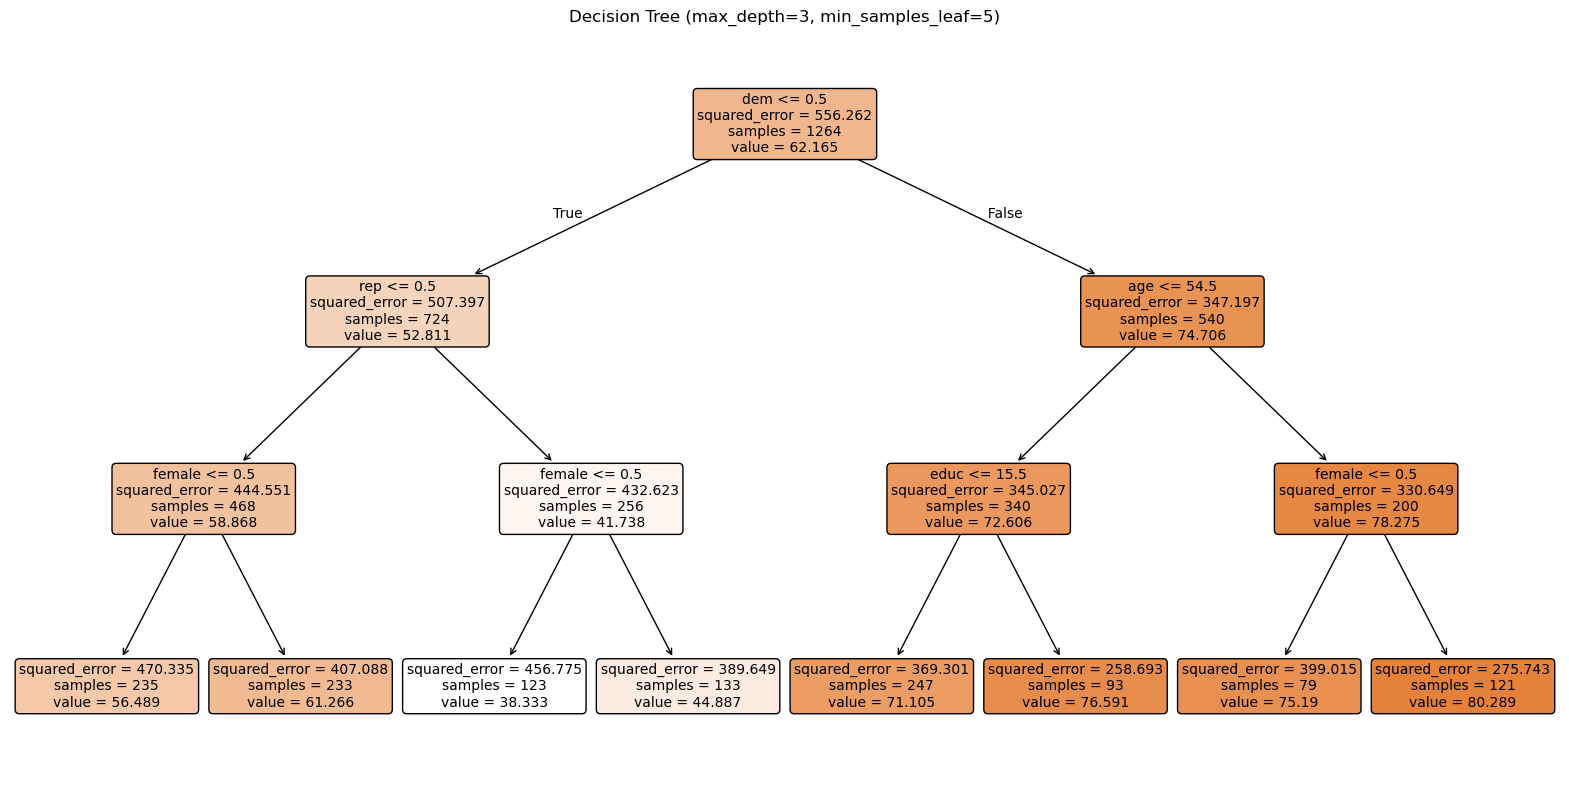


Text representation of tree:
|--- dem <= 0.50
|   |--- rep <= 0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [56.49]
|   |   |--- female >  0.50
|   |   |   |--- value: [61.27]
|   |--- rep >  0.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [38.33]
|   |   |--- female >  0.50
|   |   |   |--- value: [44.89]
|--- dem >  0.50
|   |--- age <= 54.50
|   |   |--- educ <= 15.50
|   |   |   |--- value: [71.11]
|   |   |--- educ >  15.50
|   |   |   |--- value: [76.59]
|   |--- age >  54.50
|   |   |--- female <= 0.50
|   |   |   |--- value: [75.19]
|   |   |--- female >  0.50
|   |   |   |--- value: [80.29]



In [5]:
# ---------- Part 1: simple decision tree ----------
print("\n" + "="*50)
print("PART 1: Basic Decision Tree")
print("="*50)

dt_simple = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=RANDOM_STATE)
dt_simple.fit(X_train, y_train)
y_test_pred_simple = dt_simple.predict(X_test)
test_mse_simple = mean_squared_error(y_test, y_test_pred_simple)
print(f"Decision Tree (depth=3, min_samples_leaf=5) Test MSE: {test_mse_simple:.4f}")

# Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(dt_simple, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree (max_depth=3, min_samples_leaf=5)")
plt.tight_layout()
plt.savefig("decision_tree_depth3.png", bbox_inches='tight', dpi=150)
plt.show()

# Print text version
print("\nText representation of tree:")
print(export_text(dt_simple, feature_names=list(X.columns)))



The simple decision tree (max_depth=3, min_samples_leaf=5) produced a test MSE of 396.19. The exported tree and text show the top splitting feature is the most important driver of predicted Biden score in this small, highly interpretable model. Because the tree is shallow, each leaf represents a fairly large subgroup (easy to describe): the first split separates the population by a single dominant feature and subsequent splits refine the prediction by one or two additional variables . The modest MSE indicates the shallow tree captures broad patterns, but it will miss fine-grained interactions and heterogeneity that a more flexible model might capture.


PART 2: Tuned Decision Tree (RandomizedSearchCV)
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Decision Tree parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 9}
Best Decision Tree CV MSE: 404.7099
Best Decision Tree Test MSE: 394.7620


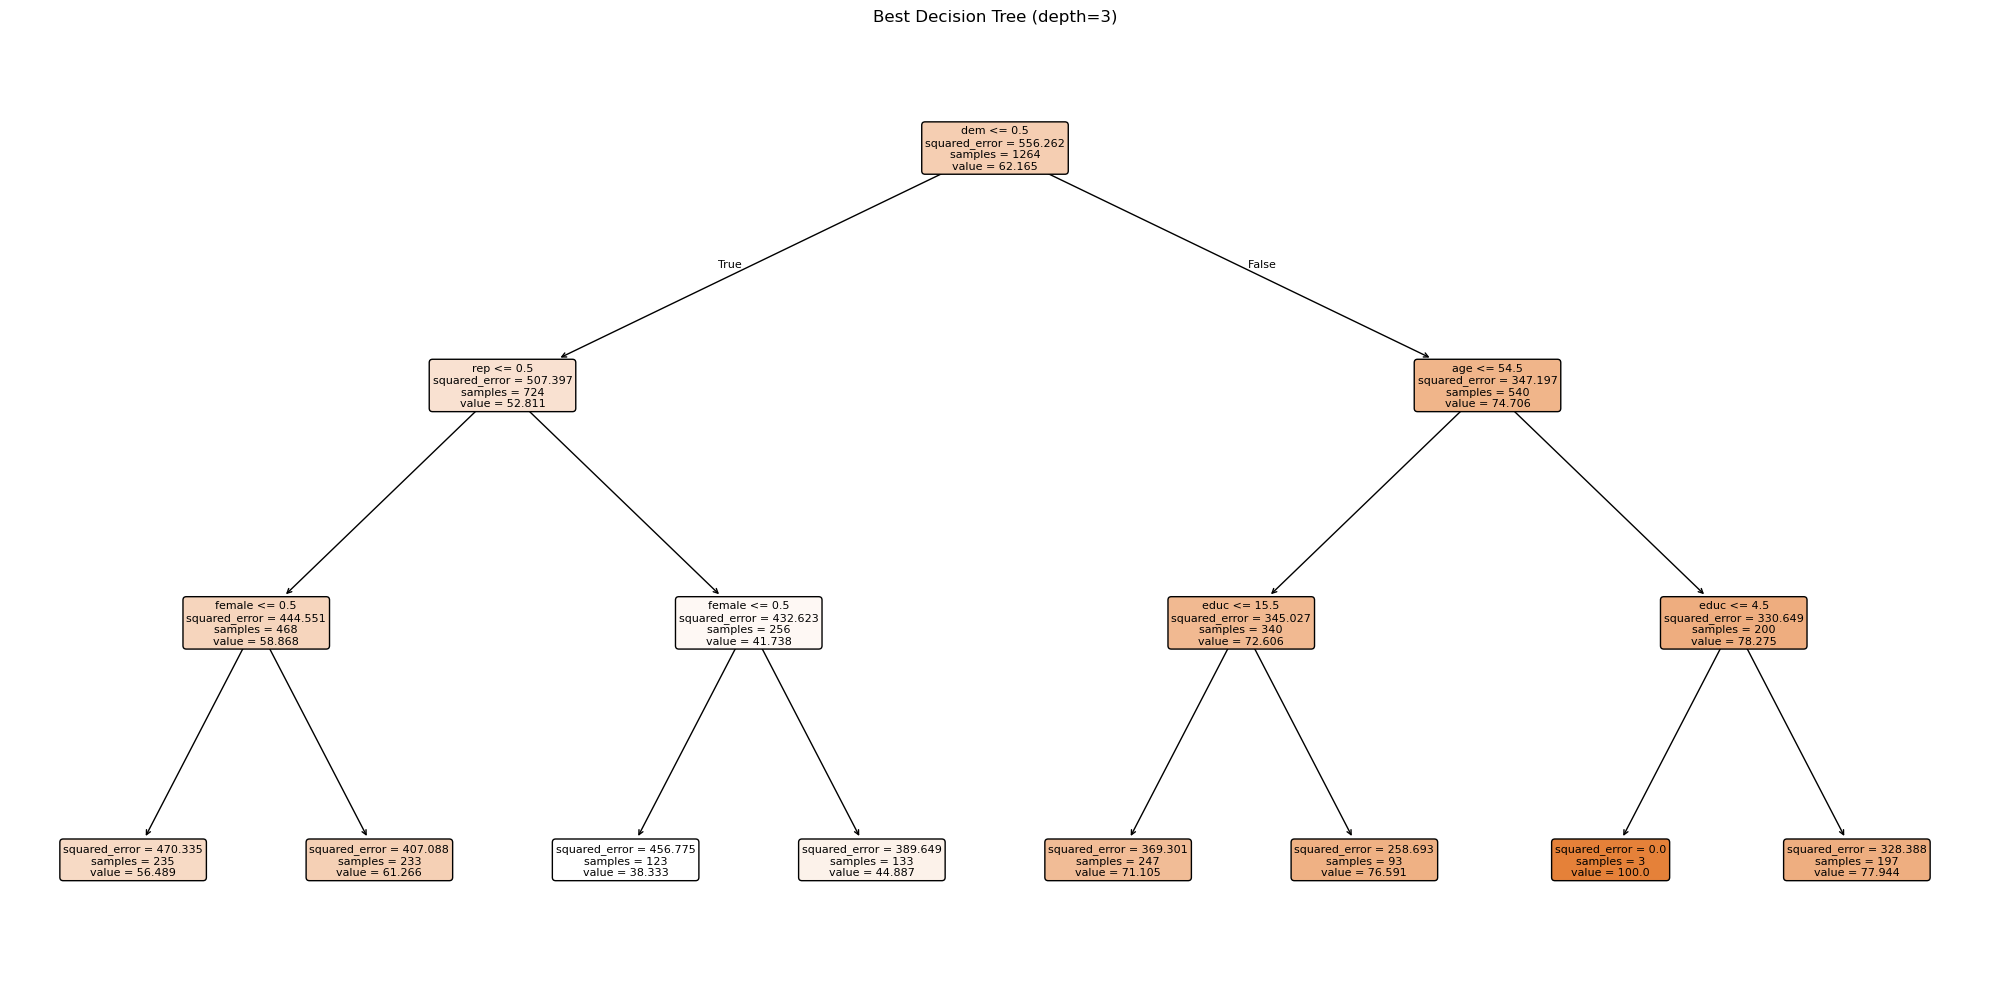

In [6]:
# ---------- Part 2: Tuned Decision Tree ----------
print("\n" + "="*50)
print("PART 2: Tuned Decision Tree (RandomizedSearchCV)")
print("="*50)

param_dist_dt = {
    'max_depth': [3, 10],  # Only these two values
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf': sp_randint(2, 20)  # Starts at 2, not 1
}

dt_base = DecisionTreeRegressor(random_state=RANDOM_STATE)

rs_dt = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dist_dt,
    n_iter=N_ITER_DT,
    scoring='neg_mean_squared_error',
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rs_dt.fit(X_train, y_train)
best_dt = rs_dt.best_estimator_
best_dt_params = rs_dt.best_params_
cv_mse_best_dt = -rs_dt.best_score_
test_mse_best_dt = mean_squared_error(y_test, best_dt.predict(X_test))


print("\nBest Decision Tree parameters:", best_dt_params)
print(f"Best Decision Tree CV MSE: {cv_mse_best_dt:.4f}")
print(f"Best Decision Tree Test MSE: {test_mse_best_dt:.4f}")

# Save and plot best tree
joblib.dump(best_dt, "best_decision_tree.pkl")

# Only plot if tree depth is reasonable
if best_dt.get_depth() <= 10:
    plt.figure(figsize=(20, 10))
    plot_tree(best_dt, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
    plt.title(f"Best Decision Tree (depth={best_dt.get_depth()})")
    plt.tight_layout()
    plt.savefig("best_decision_tree.png", bbox_inches='tight', dpi=150)
    plt.show()
else:
    print(f"Tree too deep ({best_dt.get_depth()}) to plot clearly. Check feature importances instead.")



The tuned decision tree search returned max_depth=3, min_samples_leaf=2, and min_samples_split=9 with CV MSE 404.71 and test MSE 394.76. In this run the tuned tree ended up with similar complexity to the simple tree (depth 3) but with slightly smaller leaves, which yields a small reduction in test error (394.76 vs. 396.19). The higher CV MSE (404.71) compared to the simple-tree test MSE suggests sampling noise and small-sample variability in the CV folds — the differences are small, so they may be within expectation. Overall, tuning did not produce a dramatically different structure here, which indicates that a shallow tree already captures the main signal in the dataset and deeper / more complex splits do not yield consistent improvements.


PART 3: Tuned Random Forest (RandomizedSearchCV)
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Random Forest parameters: {'max_depth': 10, 'max_features': 2, 'min_samples_leaf': 19, 'min_samples_split': 11, 'n_estimators': 200}
Best Random Forest CV MSE: 397.6405
Best Random Forest Test MSE: 392.2960


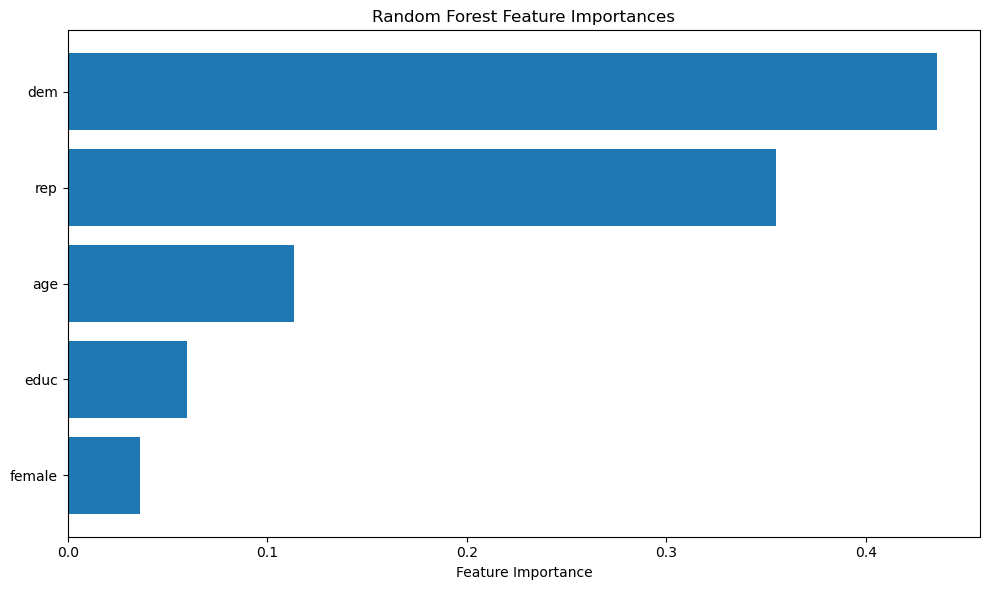


Feature Importances (Random Forest):
  female: 0.0361
  educ: 0.0598
  age: 0.1136
  rep: 0.3551
  dem: 0.4355

FINAL RESULTS SUMMARY
               Model   Test MSE      CV MSE
Simple Decision Tree 396.193715           -
 Tuned Decision Tree 394.762000  404.709941
       Random Forest 392.296050  397.640526
Tuned DT vs Simple DT: +0.4%
Random Forest vs Simple DT: +1.0%
Random Forest vs Tuned DT: +0.6%

Saved files:
  ✓ decision_tree_depth3.png
  ✓ best_decision_tree.png
  ✓ rf_feature_importances.png
  ✓ best_decision_tree.pkl
  ✓ best_random_forest.pkl

Analysis complete!


In [ ]:
# ---------- Part 3: Tuned Random Forest ----------
print("\n" + "="*50)
print("PART 3: Tuned Random Forest (RandomizedSearchCV)")
print("="*50)

param_dist_rf = {
    'n_estimators': [10, 200], 
    'max_depth': [3, 10],      
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf': sp_randint(2, 20),
    'max_features': sp_randint(1, 5) 
}

rf_base = RandomForestRegressor(random_state=RANDOM_STATE)

rs_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=N_ITER_RF,
    scoring='neg_mean_squared_error',
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rs_rf.fit(X_train, y_train)
best_rf = rs_rf.best_estimator_
best_rf_params = rs_rf.best_params_
cv_mse_best_rf = -rs_rf.best_score_
test_mse_best_rf = mean_squared_error(y_test, best_rf.predict(X_test))


print("\nBest Random Forest parameters:", best_rf_params)
print(f"Best Random Forest CV MSE: {cv_mse_best_rf:.4f}")
print(f"Best Random Forest Test MSE: {test_mse_best_rf:.4f}")

# Save RF model
joblib.dump(best_rf, "best_random_forest.pkl")

# Plot feature importances
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.savefig("rf_feature_importances.png", bbox_inches='tight', dpi=150)
plt.show()

print("\nFeature Importances (Random Forest):")
for _, row in feature_importance_df.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# ---------- Final Summary ----------
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)

results = {
    'Model': ['Simple Decision Tree', 'Tuned Decision Tree', 'Random Forest'],
    'Test MSE': [test_mse_simple, test_mse_best_dt, test_mse_best_rf],
    'CV MSE': ['-', cv_mse_best_dt, cv_mse_best_rf]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

def pct_improvement(base, new):
    if base == 0:
        return float('nan')
    return ( (base - new) / base ) * 100.0

improvement_dt = pct_improvement(test_mse_simple, test_mse_best_dt)
improvement_rf_vs_simple = pct_improvement(test_mse_simple, test_mse_best_rf)
improvement_rf_vs_dt = pct_improvement(test_mse_best_dt, test_mse_best_rf)

print(f"Tuned DT vs Simple DT: {improvement_dt:+.1f}%")
print(f"Random Forest vs Simple DT: {improvement_rf_vs_simple:+.1f}%")
print(f"Random Forest vs Tuned DT: {improvement_rf_vs_dt:+.1f}%")


# Check saved files
print("\nSaved files:")
saved_candidates = ["decision_tree_depth3.png", "rf_feature_importances.png",
                    "best_decision_tree.pkl", "best_random_forest.pkl"]
# include best_decision_tree.png only if it was created earlier
if 'best_dt' in locals() and best_dt.get_depth() <= 10:
    saved_candidates.insert(1, "best_decision_tree.png")

for fname in saved_candidates:
    exists = "✓" if os.path.exists(fname) else "✗"
    print(f"  {exists} {fname}")

print("\nAnalysis complete!")

The Random Forest tuning selected n_estimators=200, max_depth=10, max_features=2, min_samples_leaf=19, and min_samples_split=11, achieving CV MSE 397.64 and test MSE 392.30 (the best test MSE of the three models). The feature-importance plot shows that the partisan indicators (e.g., dem, rep) are the dominant predictors, with demographic features contributing less. The RF’s lower test MSE compared to both single trees indicates that ensemble averaging reduced variance and improved prediction stability. Note the tuned RF’s min_samples_leaf being large (19) and max_depth=10 suggest the forest uses many shallow-ish trees with sizable leaves — a regularized ensemble that avoids overfitting while capturing some non-linear interactions.